In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow,
    line
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions
import tempfile

# Load CovFit model

In [4]:
MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
FOLD_IDS_TO_USE = [0]
TARGET_FOLD_ID = 0
OUTPUT_PREFIX = "inference_results"
model_name = "facebook/esm2_t33_650M_UR50D"

device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [5]:
def download_hf_checkpoints(repo_id, fold_ids):
    """
    Download specified fold checkpoint files from Hugging Face
    Hugging Faceから指定されたfoldのckptファイルをダウンロード
    
    Note: The model repository is public, so no token is required.
    注意：モデルリポジトリは公開されているため、トークンは不要です。
    """
    print(f"Downloading checkpoints from {repo_id} for folds: {fold_ids}")
    model_paths = []
    temp_dir = tempfile.mkdtemp()
    
    try:
        for fold_id in fold_ids:
            filename = f"covfit_model_20231102_{fold_id}.ckpt"
            print(f"Downloading {filename}...")
            
            # Download (no token needed for public repository)
            # ダウンロード（公開リポジトリのためトークン不要）
            downloaded_path = hf_hub_download(
                repo_id=repo_id,
                filename=filename,
                cache_dir=temp_dir
            )
            model_paths.append(downloaded_path)
            
        print(f"Successfully downloaded {len(model_paths)} checkpoint files")
        return model_paths, temp_dir
        
    except Exception as e:
        # Clean up temporary directory on failure
        # 失敗時はテンポラリディレクトリをクリーンアップ
        shutil.rmtree(temp_dir, ignore_errors=True)
        raise e

In [6]:
model_paths, temp_dir = download_hf_checkpoints(
    repo_id=MODEL_PATH,
    fold_ids=FOLD_IDS_TO_USE
)

task_dict_path = hf_hub_download(
    repo_id=MODEL_PATH,
    filename="task_id_dict.pt"
)

checkpoint = torch.load(model_paths[0], map_location=device)
final_weights = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

original_task_id_infos = torch.load(task_dict_path, map_location=device)
n_targets_original = len(original_task_id_infos)

model_config = ModelConfig()
model_config.da_model_name = model_name

model = load_model_for_inference(model_paths[0], model_config, n_targets_original)
esm_fine_tuned = model.merge_and_unload() #merge PEFT adapter model with the base model and make a fully new model

# dumb thing to make hooked esm and this esm agree
esm_fine_tuned.esm.embeddings.token_dropout = False

# clean up after installing
if temp_dir and os.path.exists(temp_dir):
    shutil.rmtree(temp_dir, ignore_errors=True)
    print("Temporary files cleaned up")

covfit_model_20231102_0.ckpt:   0%|          | 0.00/2.64G [00:00<?, ?B/s]

Successfully downloaded 1 checkpoint files
Temporary files cleaned up


In [7]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [8]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name

REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [9]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}

In [10]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [11]:
# clean up memory
del model
torch.cuda.empty_cache()

# Load Data

In [12]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [13]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [14]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [15]:
uniq_seqs = []
for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs_suff, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 
    uniq_seqs.extend(uniq_seqs_suff)

In [16]:
# identical code to how it's compute_node_embeddings.py
cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

tok_output = tokenizer(cut_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)


print(pathogen_name)
print(f"Number unique sequences: {len(cut_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4382
torch.Size([4382, 1024])


In [17]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [18]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [19]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [20]:
batch_len = 50
num_data = tok_seqs.size(0)
output_logits = torch.zeros(num_data, d_out_vocab).to(device)
for i in tqdm(range(0,num_data,batch_len)):
    batch_output = get_logit_hooked(hooked_esm(tok_seqs[i:i+batch_len]), list(range(d_out_vocab)))
    output_logits[i:i+batch_len] = batch_output
    torch.cuda.empty_cache()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [04:26<00:00,  3.03s/it]


In [21]:
logit_id = original_task_id_infos["fitness_USA"]
# logit_id = original_task_id_infos["fitness_South Korea"]

In [22]:
topk = 50
high_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=True).indices
low_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=False).indices[list(range(topk-1,-1,-1))]

high_toks = tok_seqs[high_fitness_dset_indices, :]
low_toks = tok_seqs[low_fitness_dset_indices, :]
fitness_dset = torch.cat([low_toks, high_toks], dim=0)

In [23]:
high_logit_mean = get_logit_hooked(hooked_esm(high_toks), logit_id).mean().item()
low_logit_mean = get_logit_hooked(hooked_esm(low_toks), logit_id).mean().item()
print(high_logit_mean - low_logit_mean)
torch.cuda.empty_cache()

0.06285688281059265


# Curating new fitness with low-mutation dataset

In [234]:
MAX_HAM_DIST = 1
topk = 50

In [235]:
ham_dists = torch.zeros(num_data, num_data)
for i in range(0,num_data, 200):
    dists_i = (tok_seqs[:,None,:] != tok_seqs[None,i:i+200,:]).sum(dim=-1) # [num_data, 200]
    ham_dists[:, i:i+200] = dists_i
    
mask_row, mask_col = torch.triu_indices(num_data,num_data)
ham_dists[mask_row, mask_col] = MAX_HAM_DIST + 1 # mask out all upper-tri matrix

min_ham_idx = torch.argwhere(ham_dists <= MAX_HAM_DIST).cpu()
# low_ham_fit_diffs = (output_logits[min_ham_idx[:,0], logit_id] - output_logits[min_ham_idx[:,1], logit_id]).abs().cpu()

In [236]:
clean_tok_idxs = []
corr_tok_idxs = []

min_ham_idx1 = min_ham_idx[:,0]
min_ham_idx2 = min_ham_idx[:,1]
mask_idx = torch.tensor([True for _ in range(min_ham_idx.size(0))])

for i in tqdm(range(topk)):
    if mask_idx.sum() == 0:
        break

    curr_idx1 = min_ham_idx1[mask_idx]
    curr_idx2 = min_ham_idx2[mask_idx]
    
    excl_fit_diffs = (output_logits[curr_idx1, logit_id] - output_logits[curr_idx2, logit_id]).abs().argmax().item()
    clean_tok_idxs.append(curr_idx1[excl_fit_diffs].item())
    corr_tok_idxs.append(curr_idx2[excl_fit_diffs].item())

    excl_mask_idx = torch.logical_and(min_ham_idx1 != clean_tok_idxs[-1], min_ham_idx2 != corr_tok_idxs[-1])
    mask_idx = torch.logical_and(mask_idx, excl_mask_idx)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 926.88it/s]


In [245]:
new_idx_dict = {
    "clean_idx":clean_tok_idxs,
    "corr_idx":corr_tok_idxs,
}

with open("./curated_fitness_dset_indices.json", "w") as f:
    json.dump(new_idx_dict, f)

# Loading pre-curated data

In [24]:
with open("./curated_fitness_dset_indices.json", "r") as f:
    new_idx_dict = json.load(f)
    clean_tok_idxs = new_idx_dict["clean_idx"]
    corr_tok_idxs = new_idx_dict["corr_idx"]

In [25]:
# sanity check 
print(np.any([x == y for (x,y) in zip(clean_tok_idxs, corr_tok_idxs)]))

print((tok_seqs[clean_tok_idxs] != tok_seqs[corr_tok_idxs]).sum(dim=-1).float().mean())
print((output_logits[clean_tok_idxs, logit_id] - output_logits[corr_tok_idxs, logit_id]).abs().mean())

False
tensor(1., device='cuda:0')
tensor(0.0174, device='cuda:0')


min fitness diff: 0.0121 
max fitness diff: 0.0382


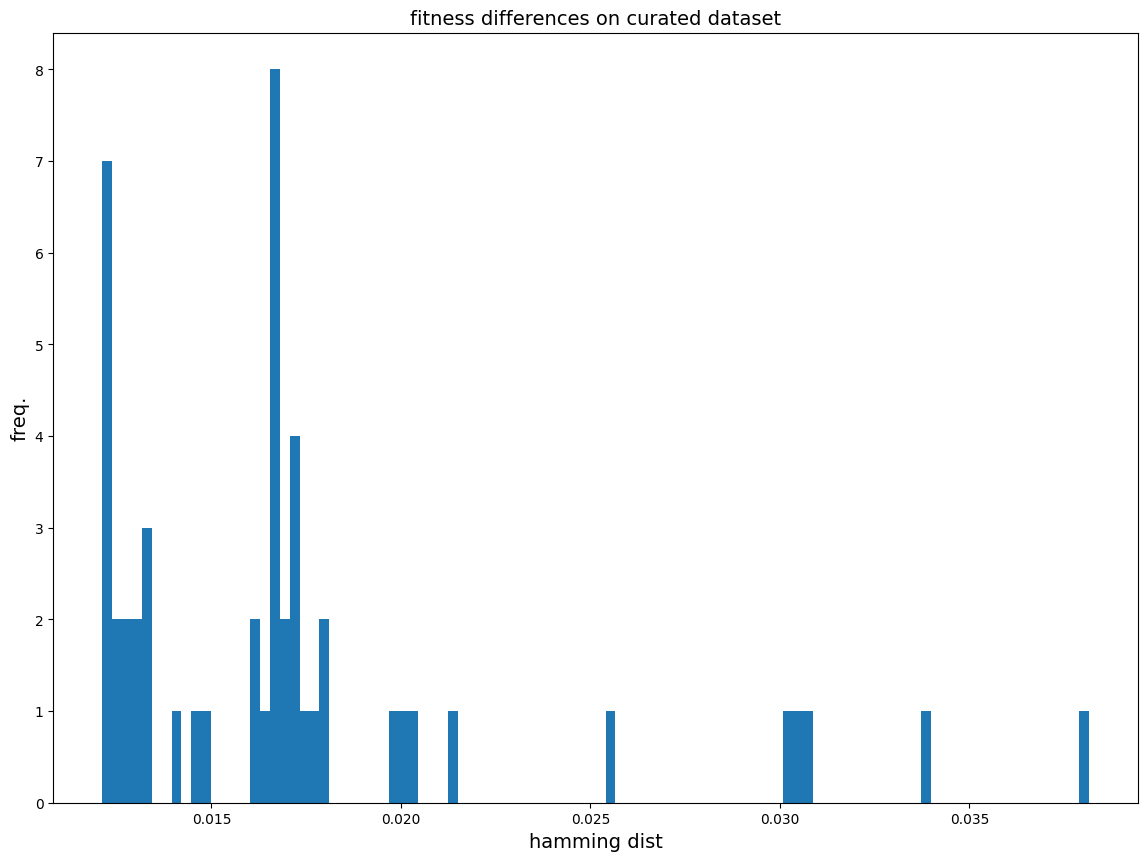

In [26]:
curated_fit_diffs = (output_logits[clean_tok_idxs, logit_id] - output_logits[corr_tok_idxs, logit_id]).abs().cpu().numpy()
print("min fitness diff: %.4f"%curated_fit_diffs.min(), "\nmax fitness diff: %.4f"%curated_fit_diffs.max())
fig,ax = plt.subplots(1,1,figsize=(14,10))
ax.hist(curated_fit_diffs, bins=100)
ax.set_title("fitness differences on curated dataset", fontsize=14)
ax.set_ylabel("freq.", fontsize=14)
ax.set_xlabel("hamming dist", fontsize=14)
plt.show()